In [1]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [51]:
# Load libraries
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import shutil
import torch

from PIL import Image
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

In [ ]:
# Read the metadata CSV file and prepare the dataset
metadata = pd.read_csv('dataset/metadata.csv')
metadata = metadata[['image_id', 'sat_image_path', 'mask_path', 'split']]

# Convert relative paths to full paths
metadata['sat_image_path'] = metadata['sat_image_path'].apply(lambda x: os.path.join('dataset', x))
metadata['mask_path'] = metadata['mask_path'].apply(lambda x: os.path.join('dataset', x) if isinstance(x, str) else None)

metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the dataset

def is_valid_image(image_path):
    Image.open(image_path).verify()
    return True

# Remove invalid or corrupted images
metadata = metadata[metadata['sat_image_path'].apply(is_valid_image) & 
                    metadata['mask_path'].apply(lambda x: is_valid_image(x) if isinstance(x, str) else True) # Keep rows where mask_path is None or valid
                    ].reset_index(drop=True)

# Split the dataset into training, validation, and test sets based on the 'split' column
train_df = metadata[metadata['split'] == 'train']
test_df = metadata[metadata['split'] == 'test']
validation_df = metadata[metadata['split'] == 'valid']

# Reset the indices of the DataFrames
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Training set size: {len(train_df)}')
print(f'Validation set size: {len(validation_df)}')
print(f'Test set size: {len(test_df)}')

# Get the class names and their corresponding RGB values from the class dictionary
class_dict = pd.read_csv('dataset/class_dict.csv')
class_names = class_dict['name'].tolist()
class_rgb_values = class_dict[['r', 'g', 'b']].values.tolist()

Training set size: 803
Validation set size: 171
Test set size: 172
Mapping RGB values to class names: {(0, 255, 255): 'urban_land', (255, 255, 0): 'agriculture_land', (255, 0, 255): 'rangeland', (0, 255, 0): 'forest_land', (0, 0, 255): 'water', (255, 255, 255): 'barren_land', (0, 0, 0): 'unknown'}


In [65]:
# Convert RGB masks to class label masks
def rgb_to_class_mask(rgb_mask, class_rgb_values):
    height, width, _ = rgb_mask.shape # Get the height and width of the RGB mask
    class_mask = np.zeros((height, width), dtype=np.uint8)

    # Iterate through each class RGB value and create a binary mask for that class
    for class_index, rgb_value in enumerate(class_rgb_values):
        matches = np.all(rgb_mask == rgb_value, axis=-1)
        class_mask[matches] = class_index

    return class_mask

# Define image normalization parameters (mean and standard deviation) for the satellite images
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]

def denormalize_image(image):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy()
    
    image = image.transpose(1, 2, 0) # Convert from (C, H, W) to (H, W, C)
    image = (image * IMAGE_STD) + IMAGE_MEAN # Denormalize the image
    image = np.clip(image, 0, 1)
    return image

class SegmentationTransforms:
    def __init__(self, image_size=256, train=True):
        self.image_size = image_size
        self.train = train
    
    def __call__(self, image, mask):
        # Resize the image
        image = TF.resize(image, (self.image_size, self.image_size), interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (self.image_size, self.image_size), interpolation=InterpolationMode.NEAREST)

        # Apply data augmentation only during training
        if self.train:
            # Random horizontal flip
            if torch.rand(1) < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random vertical flip
            if torch.rand(1) < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
            
            # Random rotation
            angle = torch.randint(0, 4, (1,)).item() * 90 # Rotate by 0, 90, 180, or 270 degrees
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
        
        # Normalize the image
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=IMAGE_MEAN, std=IMAGE_STD)

        return image, mask
    
class DeepGlobeDataset(Dataset):
    def __init__(self, dataframe, class_rgb_values, transforms=None):
        self.dataframe = dataframe.reset_index(drop=True) # Reset the index of the dataframe
        self.class_rgb_values = np.array(class_rgb_values, dtype=np.uint8)
        self.transforms = transforms # Store the transformations to be applied to the images and masks
    
    def __len__(self):
        return len(self.dataframe)
    
    # Get an item from the dataset at the specified index
    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, 'sat_image_path']
        mask_path = self.dataframe.loc[index, 'mask_path']

        # Load the image and mask using PIL and convert them to RGB format
        image = Image.open(image_path).convert('RGB')
        mask = Image.open(mask_path).convert('RGB')

        # Apply the transformations to the image and mask if they are defined
        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        # Convert the RGB mask to a class label mask using the defined function
        mask_np = np.array(mask, dtype=np.uint8)
        class_mask = rgb_to_class_mask(mask_np, self.class_rgb_values)

        # Convert the class label mask to a PyTorch tensor
        mask_tensor = torch.tensor(class_mask, dtype=torch.long)

        return image, mask_tensor

In [82]:
train_transform = SegmentationTransforms(image_size=256, train=True)
val_transform = SegmentationTransforms(image_size=256, train=False)
test_transform = SegmentationTransforms(image_size=256, train=False)

# Create datasets for training, validation, and testing
train_dataset = DeepGlobeDataset(train_df, class_rgb_values, transforms=train_transform)
val_dataset = DeepGlobeDataset(validation_df, class_rgb_values, transforms=val_transform)
test_dataset = DeepGlobeDataset(test_df, class_rgb_values, transforms=test_transform)

print(f'Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}')

# Create DataLoaders for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Train: 803, Validation: 171, Test: 172


In [73]:
# Helper function to visualize data
def visualize(images):
    n_images = len(images)
    plt.figure(figsize=(15, 5))

    # Iterate through the images and display them in a grid
    for i, (name, image) in enumerate(images):
        plt.subplot(1, n_images, i + 1)
        plt.title(name.replace('_', ' ').title(), fontsize=16)
        plt.axis('off')

        # Handle torch tensors
        if isinstance(image, torch.Tensor):
            image = image.detach().cpu().numpy()
            if image.ndim == 3 and image.shape[0] in [1, 3]:
                image = np.transpose(image, (1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
        plt.imshow(image)
    plt.tight_layout()
    plt.show()

# Perform one hot encoding of the class labels
def one_hot_encode(mask, class_rgb_values):
    mask = np.array(mask)
    encoding= []

    # Create a binary mask for each class
    for rgb in class_rgb_values:
        match = np.all(mask == rgb, axis=-1) # Check if all channels match the RGB value
        encoding.append(match)
    encoding = np.stack(encoding, axis=-1).astype(np.float32)
    return encoding

# Reverse one hot encode labels to get the original class labels
def reverse_one_hot(mask):
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    
    # Get the index of the maximum value along the last axis (class dimension)
    x = np.argmax(mask, axis=-1)
    return x

# Color coding the reverse one hot encoded labels to visualize the segmentation results
def colour_code_segmentation(mask, class_rgb_values):
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()

    mask = mask.astype(int)
    colour_codes = np.array(class_rgb_values)

    return colour_codes[mask] # Map each class label to its corresponding RGB color code

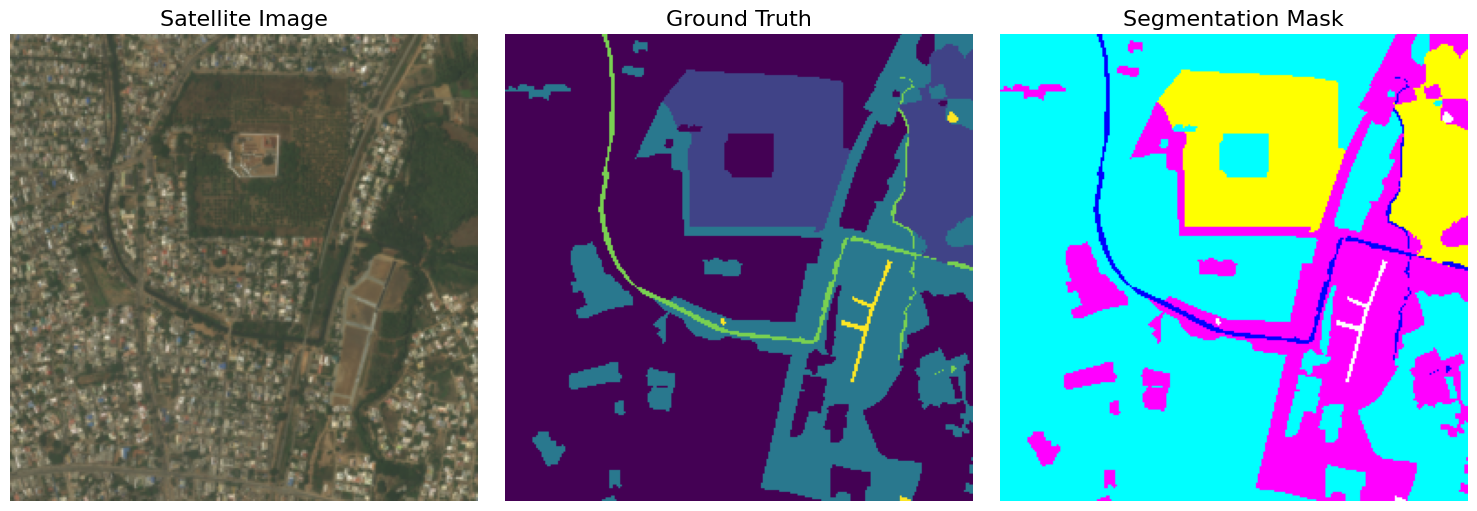

In [ ]:
# Get the first image and mask from the training dataset
image, mask = train_dataset[10]

img_visualization = denormalize_image(image)
mask_visualization = colour_code_segmentation(mask, class_rgb_values)
one_hot_encoded_mask = one_hot_encode(mask_visualization, class_rgb_values)
reverse_encoded_mask = reverse_one_hot(one_hot_encoded_mask)

visualize([('Satellite Image', img_visualization), ('Ground Truth Mask', reverse_encoded_mask), ('Segmentation Mask', mask_visualization)])

In [ ]:
# Fully Convolutional Neural Network (FCN)


In [ ]:
# U-Net

In [ ]:
# DeepLabV3+

In [ ]:
# SegFormer